In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
import pandas as pd

file_path = "streamflowwithLags.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)



['Sheet1', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Lag6']


In [3]:


file_path = "streamflowwithLags.xlsx"

lag1_data = pd.read_excel(file_path, sheet_name="Lag1")

lag1_data.head()


,Q(t-1),Q(t)
0,6.543901,4.68146
1,10.389399,33.849901
2,6.926266,98.444705
3,12.170126,314.359768
4,99.349307,378.266665


In [4]:
X = lag1_data[['Q(t-1)']]
y = lag1_data['Q(t)']


In [5]:
# convert entire columns to numeric forcefully
lag1_data['Q(t-1)'] = pd.to_numeric(lag1_data['Q(t-1)'], errors='coerce')
lag1_data['Q(t)'] = pd.to_numeric(lag1_data['Q(t)'], errors='coerce')



In [6]:
lag1_data = lag1_data.dropna()


In [7]:
X = lag1_data[['Q(t-1)']]
y = lag1_data['Q(t)']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, shuffle=False
)

model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=500)
model.fit(X_train, y_train.ravel())

y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("Lag-1 RMSE:", rmse)
print("Lag-1 R2:", r2)


Lag-1 RMSE: 102.1111860272669
Lag-1 R2: -0.02069879383253692


In [9]:
lag2 = pd.read_excel(file_path, sheet_name="Lag2")

# clean
lag2 = lag2.apply(pd.to_numeric, errors='coerce').dropna()

X = lag2[['Q(t-2)','Q(t-1)']]
y = lag2['Q(t)']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, shuffle=False
)

model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=500)
model.fit(X_train, y_train.ravel())

y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1,1))

rmse2 = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r22 = r2_score(y_test_actual, y_pred_actual)

print("Lag-2 RMSE:", rmse2)
print("Lag-2 R2:", r22)


Lag-2 RMSE: 141.57670035228992
Lag-2 R2: -0.09967765810279783


In [10]:
lag3 = pd.read_excel(file_path, sheet_name="Lag3")

lag3 = lag3.apply(pd.to_numeric, errors='coerce').dropna()

X = lag3[['Q(t-3)','Q(t-2)','Q(t-1)']]
y = lag3['Q(t)']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, shuffle=False
)

model = MLPRegressor(hidden_layer_sizes=(10,), max_iter=500)
model.fit(X_train, y_train.ravel())

y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1,1))

rmse3 = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r23 = r2_score(y_test_actual, y_pred_actual)

print("Lag-3 RMSE:", rmse3)
print("Lag-3 R2:", r23)


Lag-3 RMSE: 107.66541121033214
Lag-3 R2: 0.36430403528089184


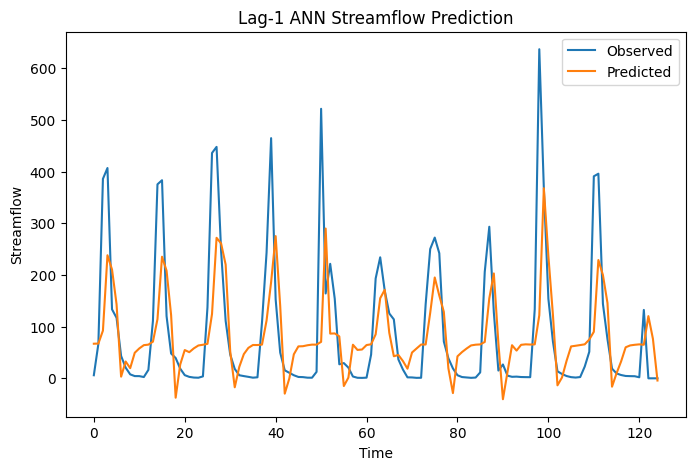

In [11]:
plt.figure(figsize=(8,5))
plt.plot(y_test_actual, label="Observed")
plt.plot(y_pred_actual, label="Predicted")
plt.legend()
plt.title("Lag-1 ANN Streamflow Prediction")
plt.xlabel("Time")
plt.ylabel("Streamflow")
plt.show()


In [16]:
import pandas as pd

# change ONLY this line if needed:
file_path = "streamflowwithLags.xlsx"


lag1 = pd.read_excel(file_path, sheet_name="Lag1")
lag2 = pd.read_excel(file_path, sheet_name="Lag2")
lag3 = pd.read_excel(file_path, sheet_name="Lag3")
lag4 = pd.read_excel(file_path, sheet_name="Lag4")
lag5 = pd.read_excel(file_path, sheet_name="Lag5")
lag6 = pd.read_excel(file_path, sheet_name="Lag6")

print("All lag sheets loaded successfully")


All lag sheets loaded successfully


In [17]:
import numpy as np
import matplotlib.pyplot as plt


In [18]:
def train_ann_numpy(X, y, hidden_neurons=10, lr=0.01, epochs=500):

    input_neurons = X.shape[1]
    output_neurons = 1
    
    W1 = np.random.rand(input_neurons, hidden_neurons)
    b1 = np.random.rand(1, hidden_neurons)
    
    W2 = np.random.rand(hidden_neurons, output_neurons)
    b2 = np.random.rand(1, output_neurons)
    
    for epoch in range(epochs):
        
        hidden = np.dot(X, W1) + b1
        hidden_act = 1 / (1 + np.exp(-hidden))
        
        output = np.dot(hidden_act, W2) + b2
        
        error = y.reshape(-1,1) - output
        
        d_output = error
        d_W2 = np.dot(hidden_act.T, d_output)
        d_b2 = np.sum(d_output, axis=0)
        
        d_hidden = np.dot(d_output, W2.T) * hidden_act*(1-hidden_act)
        d_W1 = np.dot(X.T, d_hidden)
        d_b1 = np.sum(d_hidden, axis=0)
        
        W1 += lr * d_W1
        b1 += lr * d_b1
        W2 += lr * d_W2
        b2 += lr * d_b2
        
    return W1, b1, W2, b2


In [19]:
def predict_ann(X, W1, b1, W2, b2):

    hidden = np.dot(X, W1) + b1
    hidden_act = 1 / (1 + np.exp(-hidden))
    
    output = np.dot(hidden_act, W2) + b2
    
    return output


In [25]:
results = {}

lag_sheets = {
    1: lag1,
    2: lag2,
    3: lag3,
    4: lag4,
    5: lag5,
    6: lag6
}

for lag, df in lag_sheets.items():
    
    print("Training for Lag", lag)
    
    df = df.dropna()
    
    X = df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').values
    y = df.iloc[:, -1].apply(pd.to_numeric, errors='coerce').values
    
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask]
    y = y[mask]
    
    # NORMALIZATION
    X = (X - np.min(X)) / (np.max(X) - np.min(X) + 1e-8)
    y = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-8)

    
    split = int(0.8 * len(X))
    
    X_train = X[:split]
    y_train = y[:split]
    
    X_test = X[split:]
    y_test = y[split:]
    
    W1, b1, W2, b2 = train_ann_numpy(X_train, y_train, lr=0.001, epochs=300)
    
    y_pred = predict_ann(X_test, W1, b1, W2, b2)
    
    mse = np.mean((y_test.reshape(-1,1) - y_pred)**2)
    
    results[lag] = mse

results


Training for Lag 1
Training for Lag 2
Training for Lag 3
Training for Lag 4
Training for Lag 5
Training for Lag 6


{1: np.float64(0.025190422699435257),
 2: np.float64(0.02962323905772852),
 3: np.float64(0.030365277387797405),
 4: np.float64(0.02816188834420827),
 5: np.float64(30.045200702891368),
 6: np.float64(0.030102703098205126)}

In [26]:
best_lag = min(results, key=results.get)
print("Best lag =", best_lag)


Best lag = 1


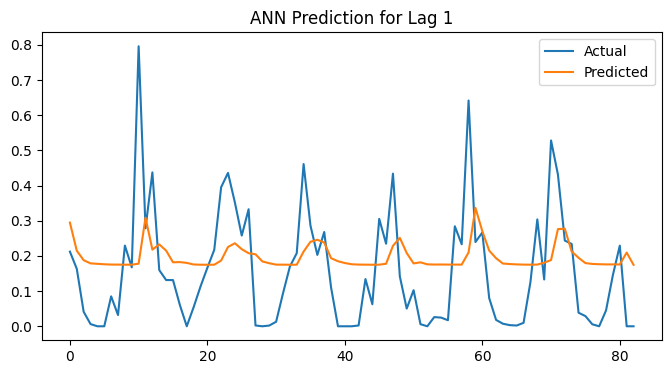

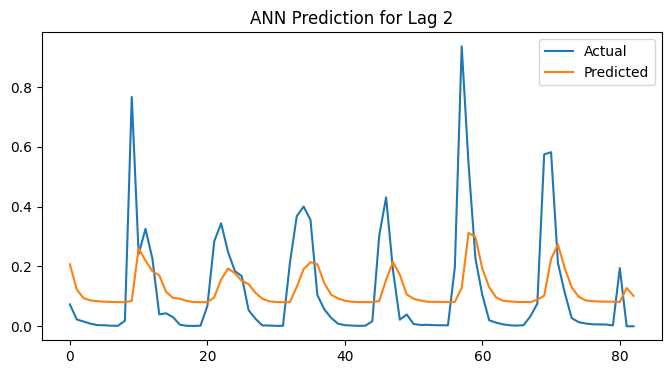

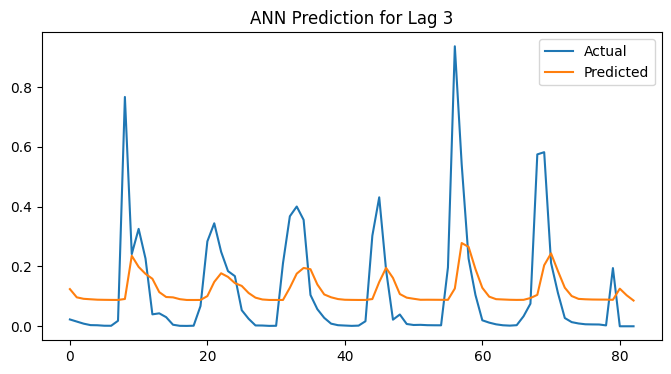

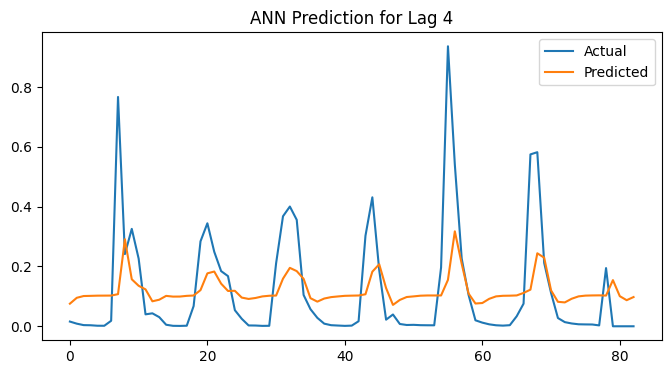

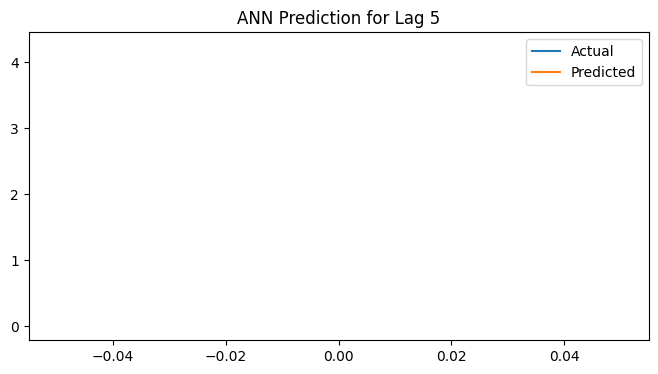

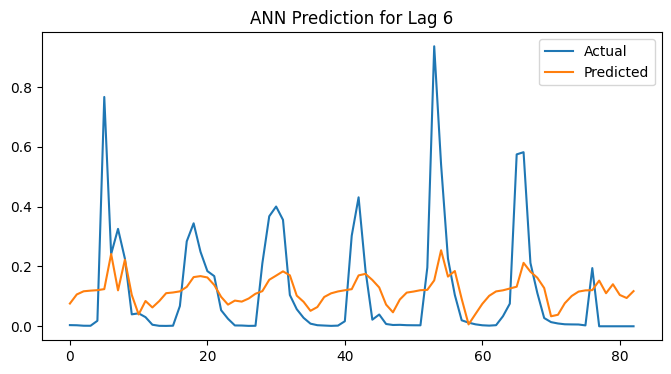

In [29]:
lag_sheets = {
    1: lag1,
    2: lag2,
    3: lag3,
    4: lag4,
    5: lag5,
    6: lag6
}

for lag, df in lag_sheets.items():
    
    df = df.dropna()
    
    X = df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').values
    y = df.iloc[:, -1].apply(pd.to_numeric, errors='coerce').values
    
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask]
    y = y[mask]
    
    # normalization
    X = (X - np.min(X)) / (np.max(X) - np.min(X) + 1e-8)
    y = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-8)

    
    split = int(0.8 * len(X))
    
    X_train = X[:split]
    y_train = y[:split]
    
    X_test = X[split:]
    y_test = y[split:]
    
    W1, b1, W2, b2 = train_ann_numpy(X_train, y_train, lr=0.001, epochs=300)
    
    y_pred = predict_ann(X_test, W1, b1, W2, b2)
    
    plt.figure(figsize=(8,4))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.title(f'ANN Prediction for Lag {lag}')
    plt.show()


In [30]:
import pandas as pd

results_table = pd.DataFrame(list(results.items()), columns=['Lag', 'MSE'])
results_table


,Lag,MSE
0,1,0.025190
1,2,0.029623
2,3,0.030365
3,4,0.028162
4,5,30.045201
5,6,0.030103


In [33]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

metrics = {}

for lag, df in lag_sheets.items():
    
    df = df.dropna()
    
    X = df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').values
    y = df.iloc[:, -1].apply(pd.to_numeric, errors='coerce').values
    
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask]
    y = y[mask]
    
    # normalization
    X = (X - np.min(X)) / (np.max(X) - np.min(X) + 1e-8)
    y = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-8)
    
    split = int(0.8 * len(X))
    
    X_train = X[:split]
    y_train = y[:split]
    
    X_test = X[split:]
    y_test = y[split:]
    
    W1, b1, W2, b2 = train_ann_numpy(X_train, y_train, lr=0.001, epochs=300)
    
    y_pred = predict_ann(X_test, W1, b1, W2, b2)
    
    mse = np.mean((y_test.reshape(-1,1) - y_pred)**2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    metrics[lag] = [rmse, r2]

# create table
rmse_r2_table = pd.DataFrame(metrics).T
rmse_r2_table.columns = ['RMSE', 'R2']

rmse_r2_table


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,RMSE,R2
1,0.160099,0.042741
2,0.174903,0.110536
3,0.164723,0.214276
4,0.167451,0.189386
5,4.992570,NaN
6,0.176799,0.098028
